# E-Commerce Customer Segmentation
## Project Progress - Checkpoint 2
### Dataset: Online Retail II

This notebook extends the Checkpoint 1 pipeline by:
- reusing the cleaned transaction pipeline
- building RFM customer features
- engineering additional behavioral features
- comparing multiple clustering methods
- evaluating results using clustering metrics
- selecting the best model
- interpreting final customer segments


## 1. Import Libraries

In this section, we import all required Python libraries for data processing, visualization, and clustering.

- Pandas and NumPy are used for data manipulation.
- Matplotlib and Seaborn are used for visualization.
- Scikit-learn provides clustering algorithms and evaluation metrics.
- PCA is used for dimensionality reduction and visualization.
- Warnings are suppressed for cleaner output.

A fixed random state is used to ensure reproducibility of results.

In [167]:
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import linkage, dendrogram

sns.set_style("whitegrid")
RANDOM_STATE = 42


## 2. Load Dataset

The dataset is loaded  Excel (.xlsx) using openpyxl a flexible loading function and the dataset is then inspected by printing its shape and previewing the first few rows.

In [168]:
df = pd.read_excel("online_retail_II.xlsx")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 3. Initial Inspection

In this step, we examine the dataset structure:

- Column names are cleaned to remove extra spaces
- Data types and non-null counts are checked
- Missing values are identified

This helps us understand data quality and prepare for cleaning.

In [169]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())
df.info()


['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 38.8+ MB


In [170]:
df.isnull().sum().sort_values(ascending=False)


Customer ID    107927
Description      2928
Invoice             0
StockCode           0
Quantity            0
InvoiceDate         0
Price               0
Country             0
dtype: int64

## 4. Detect Required Columns

Since different versions of the dataset may have slightly different column names, we dynamically detect:

- Price column (Price or UnitPrice)
- Customer ID column
- Invoice column
- Date column
- Quantity column

This makes the pipeline robust and adaptable to variations in the dataset.

In [171]:
price_col = next((c for c in ["Price", "UnitPrice", "Unit Price"] if c in df.columns), None)
cust_col = next((c for c in ["Customer ID", "CustomerID", "CustomerId"] if c in df.columns), None)
invoice_col = "Invoice" if "Invoice" in df.columns else "InvoiceNo"
date_col = "InvoiceDate" if "InvoiceDate" in df.columns else "Invoice Date"
qty_col = "Quantity"
desc_col = "Description" if "Description" in df.columns else None
stock_col = "StockCode" if "StockCode" in df.columns else None
country_col = "Country" if "Country" in df.columns else None

if price_col is None:
    raise KeyError(f"Price column not found. Available columns: {list(df.columns)}")
if cust_col is None:
    raise KeyError(f"Customer ID column not found. Available columns: {list(df.columns)}")

print("price_col:", price_col)
print("cust_col:", cust_col)
print("invoice_col:", invoice_col)
print("date_col:", date_col)
print("qty_col:", qty_col)
print("desc_col:", desc_col)
print("stock_col:", stock_col)
print("country_col:", country_col)


price_col: Price
cust_col: Customer ID
invoice_col: Invoice
date_col: InvoiceDate
qty_col: Quantity
desc_col: Description
stock_col: StockCode
country_col: Country


## 5. Data Cleaning

Real-world transaction data contains noise and inconsistencies.

We perform the following cleaning steps:

- Remove rows with missing Customer IDs
- Remove cancelled invoices (identified by 'C' prefix)
- Remove negative or zero quantities (returns or invalid entries)
- Remove invalid price values
- Convert the date column to datetime format

Finally, we create a new feature:
- TotalAmount = Quantity × Price

This ensures that only valid purchase transactions are used for analysis.

In [172]:
df = df.dropna(subset=[cust_col]).copy()

df[invoice_col] = df[invoice_col].astype(str)
df = df[~df[invoice_col].str.startswith("C")]

df = df[(df[qty_col] > 0) & (df[price_col] > 0)]

df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df = df.dropna(subset=[date_col])

df["TotalAmount"] = df[qty_col] * df[price_col]

print("Cleaned dataset shape:", df.shape)
df.head()


Cleaned dataset shape: (407664, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


## 6. Feature Engineering – RFM

We transform transaction-level data into customer-level behavioral features using the RFM model:

- Recency: Days since last purchase
- Frequency: Number of transactions
- Monetary: Total spending

Each customer is represented as a single row with these features.

This transformation is essential for clustering customers based on behavior.

In [173]:
snapshot_date = df[date_col].max() + pd.Timedelta(days=1)

recency = df.groupby(cust_col)[date_col].max().reset_index()
recency["Recency"] = (snapshot_date - recency[date_col]).dt.days
recency = recency[[cust_col, "Recency"]]

frequency = df.groupby(cust_col)[invoice_col].nunique().reset_index()
frequency.columns = [cust_col, "Frequency"]

monetary = df.groupby(cust_col)["TotalAmount"].sum().reset_index()
monetary.columns = [cust_col, "Monetary"]

rfm = recency.merge(frequency, on=cust_col).merge(monetary, on=cust_col)

print("RFM table shape:", rfm.shape)
rfm.head()


RFM table shape: (4312, 4)


,Customer ID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93


## 7. Additional Feature Engineering (Checkpoint 2 Improvement)

To improve the segmentation model beyond basic RFM, we introduce additional behavioral features:

- AvgOrderValue: Average spending per transaction
- AvgQtyPerInvoice: Average quantity purchased per order
- UniqueProducts: Number of unique products purchased
- PurchaseSpan: Duration between first and last purchase

These features provide richer insights into customer behavior and help improve clustering quality.

In [174]:
aov = df.groupby(cust_col).apply(
    lambda x: x["TotalAmount"].sum() / x[invoice_col].nunique()
).reset_index(name="AvgOrderValue")

avg_qty_per_invoice = df.groupby([cust_col, invoice_col])[qty_col].sum().reset_index()
avg_qty_per_invoice = avg_qty_per_invoice.groupby(cust_col)[qty_col].mean().reset_index()
avg_qty_per_invoice.columns = [cust_col, "AvgQtyPerInvoice"]

if stock_col is not None:
    unique_products = df.groupby(cust_col)[stock_col].nunique().reset_index()
else:
    unique_products = df.groupby(cust_col)[desc_col].nunique().reset_index()
unique_products.columns = [cust_col, "UniqueProducts"]

purchase_span = df.groupby(cust_col)[date_col].agg(["min", "max"]).reset_index()
purchase_span["PurchaseSpan"] = (purchase_span["max"] - purchase_span["min"]).dt.days
purchase_span = purchase_span[[cust_col, "PurchaseSpan"]]

customer_features = (
    rfm.merge(aov, on=cust_col)
       .merge(avg_qty_per_invoice, on=cust_col)
       .merge(unique_products, on=cust_col)
       .merge(purchase_span, on=cust_col)
)

customer_features.head()


,Customer ID,Recency,Frequency,Monetary,AvgOrderValue,AvgQtyPerInvoice,UniqueProducts,PurchaseSpan
0,12346.0,165,11,372.86,33.896364,6.363636,26,196
1,12347.0,3,2,1323.32,661.660000,414.000000,70,37
2,12348.0,74,1,222.16,222.160000,373.000000,20,0
3,12349.0,43,3,2671.14,890.380000,331.000000,90,181
4,12351.0,11,1,300.93,300.930000,261.000000,21,0


## 8. Exploratory Data Analysis

We analyze the distribution and relationships of features:

- Summary statistics provide an overview of feature ranges
- Histograms reveal skewness and data distribution
- Correlation heatmap shows relationships between features
- Boxplots help identify outliers

This step helps us understand the data and prepare for preprocessing.

In [175]:
customer_features.describe().transpose()


,count,mean,std,min,25%,50%,75%,max
Customer ID,4312.0,15349.290353,1701.200176,12346.00,13882.500000,15350.500000,16834.250000,18287.00
Recency,4312.0,91.171846,96.860633,1.00,18.000000,53.000000,136.000000,374.00
Frequency,4312.0,4.455705,8.170213,1.00,1.000000,2.000000,5.000000,205.00
Monetary,4312.0,2048.238236,8914.481280,2.95,307.987500,706.020000,1723.142500,349164.35
AvgOrderValue,4312.0,378.322627,492.564076,2.95,182.087857,287.368056,423.576667,11880.84
AvgQtyPerInvoice,4312.0,255.751540,1554.107975,1.00,90.000000,151.916667,257.000000,87167.00
UniqueProducts,4312.0,63.646104,85.757966,1.00,17.000000,38.000000,79.250000,1741.00
PurchaseSpan,4312.0,133.998609,132.827183,0.00,0.000000,105.000000,254.000000,373.00


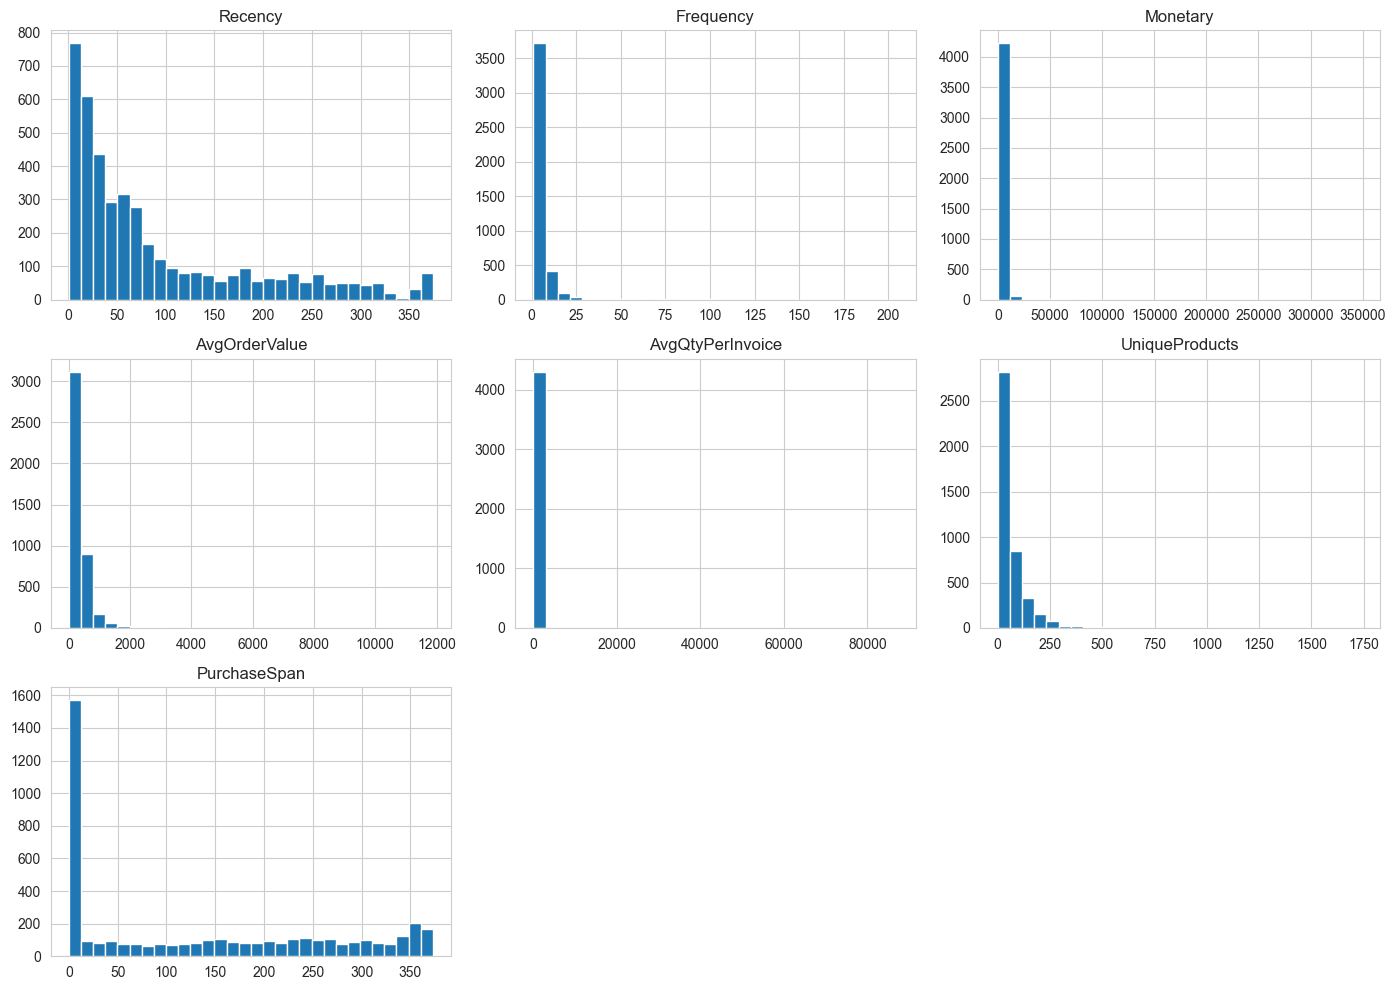

In [176]:
customer_features[
    ["Recency", "Frequency", "Monetary",
     "AvgOrderValue", "AvgQtyPerInvoice",
     "UniqueProducts", "PurchaseSpan"]
].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()


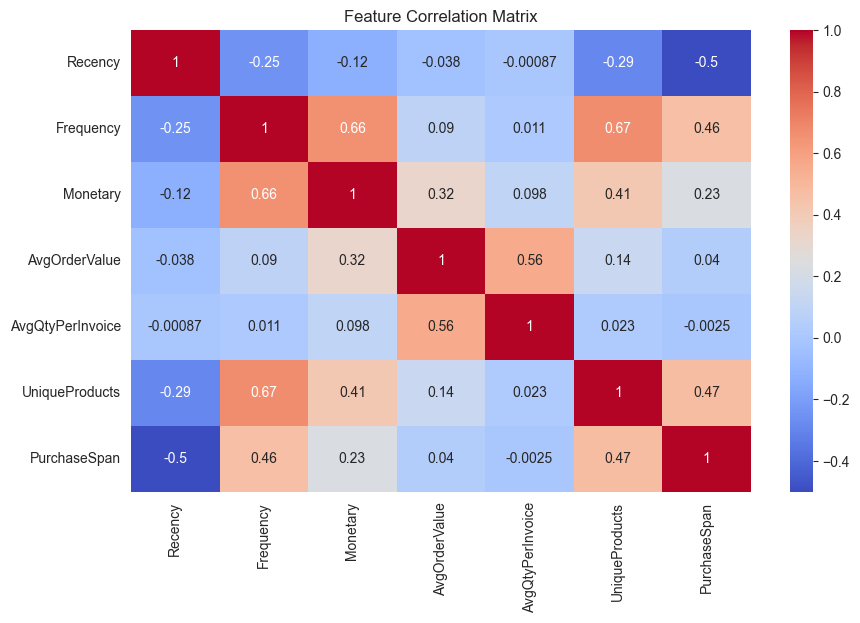

In [177]:
plt.figure(figsize=(10, 6))
sns.heatmap(customer_features.drop(columns=[cust_col]).corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()


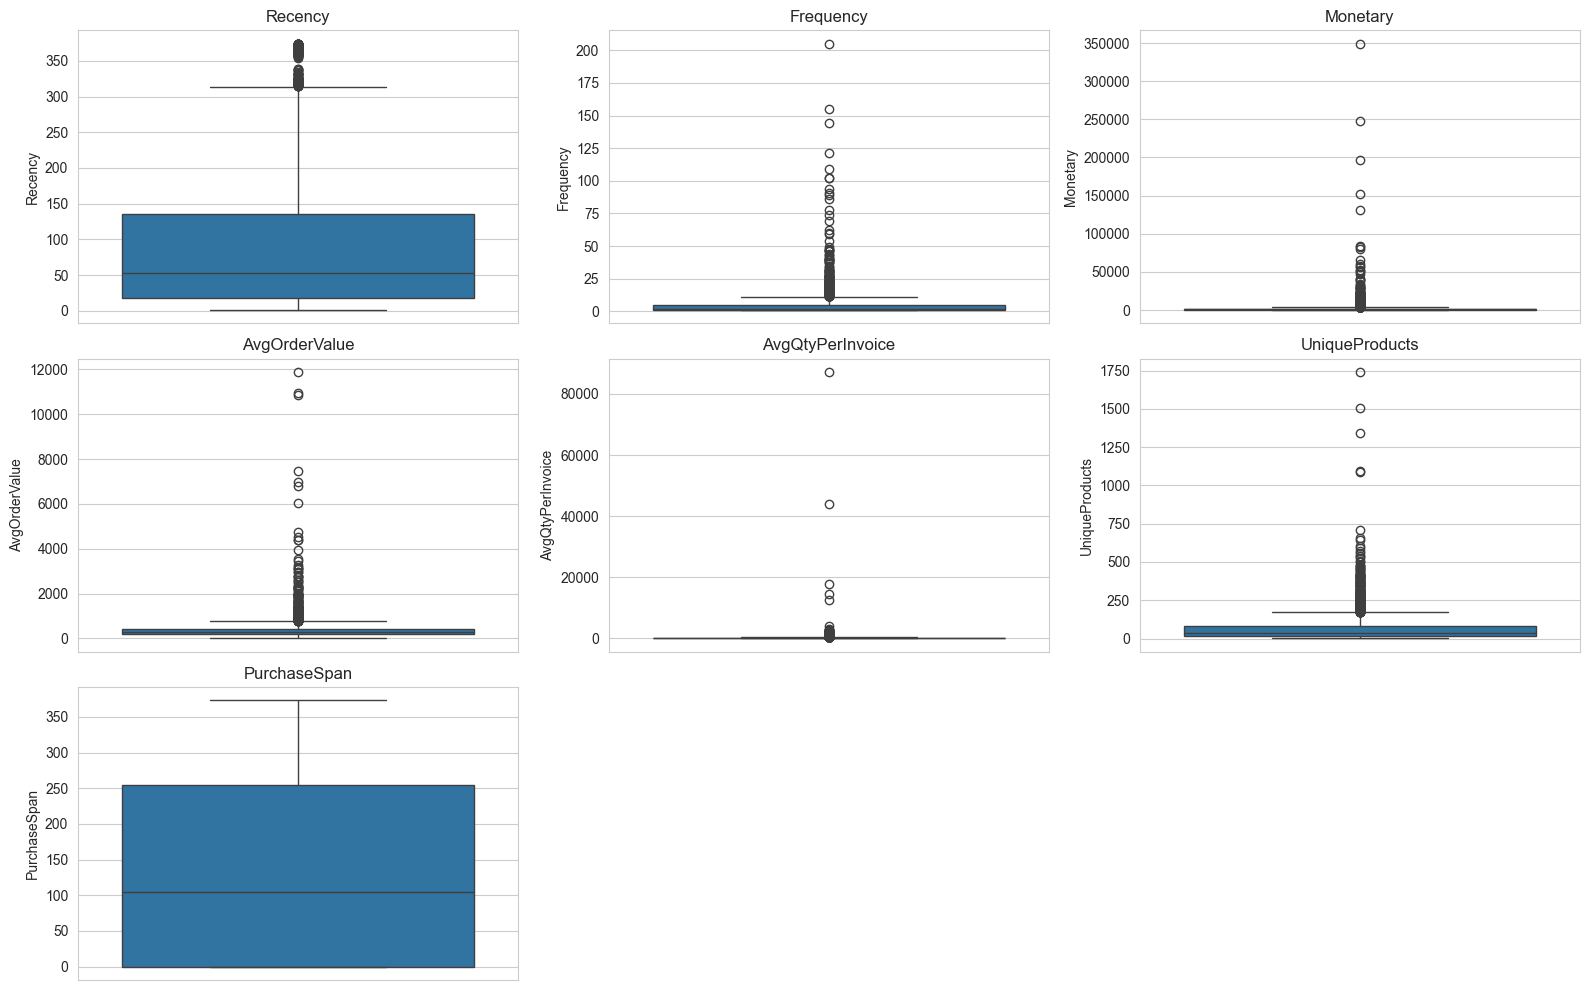

In [178]:
features_to_plot = [
    "Recency", "Frequency", "Monetary",
    "AvgOrderValue", "AvgQtyPerInvoice",
    "UniqueProducts", "PurchaseSpan"
]

plt.figure(figsize=(16, 10))
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=customer_features[col])
    plt.title(col)
plt.tight_layout()
plt.show()


## 9. Feature Set Construction

We create two datasets for comparison:

1. Baseline Feature Set:
   - RFM features only

2. Extended Feature Set:
   - RFM + additional behavioral features

This allows us to evaluate whether additional features improve clustering performance.

In [179]:
rfm_only = customer_features[[cust_col, "Recency", "Frequency", "Monetary"]].copy()
extended = customer_features.copy()

rfm_only.head(), extended.head()


(   Customer ID  Recency  Frequency  Monetary
 0      12346.0      165         11    372.86
 1      12347.0        3          2   1323.32
 2      12348.0       74          1    222.16
 3      12349.0       43          3   2671.14
 4      12351.0       11          1    300.93,
    Customer ID  Recency  Frequency  Monetary  AvgOrderValue  AvgQtyPerInvoice  \
 0      12346.0      165         11    372.86      33.896364          6.363636   
 1      12347.0        3          2   1323.32     661.660000        414.000000   
 2      12348.0       74          1    222.16     222.160000        373.000000   
 3      12349.0       43          3   2671.14     890.380000        331.000000   
 4      12351.0       11          1    300.93     300.930000        261.000000   
 
    UniqueProducts  PurchaseSpan  
 0              26           196  
 1              70            37  
 2              20             0  
 3              90           181  
 4              21             0  )

## 10. Data Preprocessing

Clustering algorithms are sensitive to scale and skewness. This ensures that all features contribute equally to clustering.

We apply:
- `log1p` transformation to reduce skewness
- `StandardScaler` to normalize feature scales


In [180]:
def preprocess_features(df_features, id_col):
    data = df_features.copy()
    feature_cols = [c for c in data.columns if c != id_col]
    data[feature_cols] = np.log1p(data[feature_cols])
    scaler = StandardScaler()
    scaled = scaler.fit_transform(data[feature_cols])
    return data, scaled, feature_cols

rfm_log, rfm_scaled, rfm_cols = preprocess_features(rfm_only, cust_col)
ext_log, ext_scaled, ext_cols = preprocess_features(extended, cust_col)

print("RFM scaled shape:", rfm_scaled.shape)
print("Extended scaled shape:", ext_scaled.shape)


RFM scaled shape: (4312, 3)
Extended scaled shape: (4312, 7)


## 11. Elbow Method for K-Means

The Elbow method helps determine the optimal number of clusters.

We compute inertia for different values of K and plot the results.

The point where the curve starts to flatten indicates a suitable number of clusters.

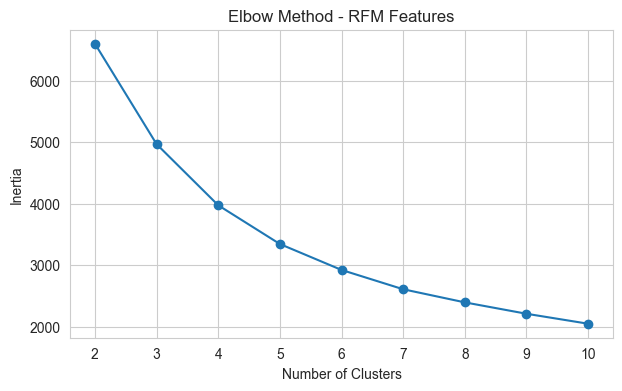

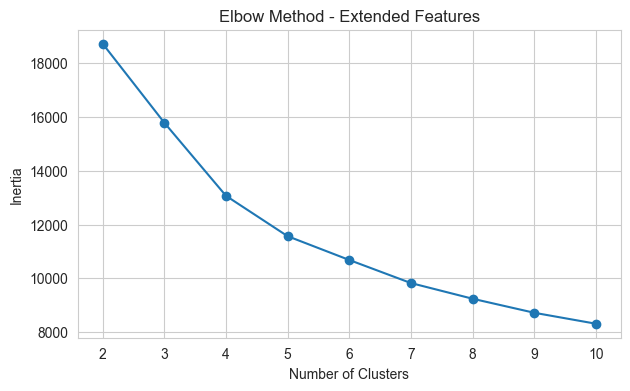

In [181]:
def plot_elbow(X, title):
    inertia = []
    k_range = range(2, 11)
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        km.fit(X)
        inertia.append(km.inertia_)

    plt.figure(figsize=(7, 4))
    plt.plot(k_range, inertia, marker="o")
    plt.title(title)
    plt.xlabel("Number of Clusters")
    plt.ylabel("Inertia")
    plt.show()

plot_elbow(rfm_scaled, "Elbow Method - RFM Features")
plot_elbow(ext_scaled, "Elbow Method - Extended Features")


## 12. Hierarchical Clustering – Dendrogram

We use a dendrogram to visualize hierarchical clustering.

This helps us:
- Understand the structure of the data
- Observe how clusters are formed
- Select an appropriate number of clusters

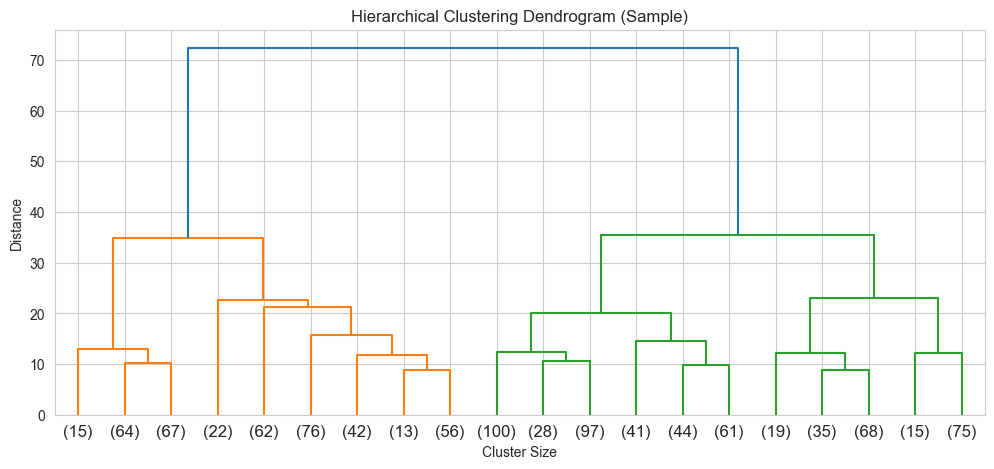

In [182]:
sample_size = min(1000, ext_scaled.shape[0])
sample_indices = np.random.RandomState(RANDOM_STATE).choice(ext_scaled.shape[0], sample_size, replace=False)
ext_sample = ext_scaled[sample_indices]

linked = linkage(ext_sample, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode="lastp", p=20)
plt.title("Hierarchical Clustering Dendrogram (Sample)")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.show()


## 13. Clustering Evaluation Metrics

We evaluate clustering performance using:

- Silhouette Score (higher is better)
- Davies-Bouldin Index (lower is better)
- Calinski-Harabasz Score (higher is better)

For DBSCAN, noise points are handled appropriately during evaluation.

This ensures fair comparison across models.

In [183]:
def evaluate_clustering(X, labels):
    unique_labels = set(labels)

    if len(unique_labels - {-1}) < 2:
        return {
            "Silhouette": np.nan,
            "DaviesBouldin": np.nan,
            "CalinskiHarabasz": np.nan
        }

    if -1 in unique_labels:
        mask = labels != -1
        X_eval = X[mask]
        labels_eval = labels[mask]
    else:
        X_eval = X
        labels_eval = labels

    if len(set(labels_eval)) < 2:
        return {
            "Silhouette": np.nan,
            "DaviesBouldin": np.nan,
            "CalinskiHarabasz": np.nan
        }

    return {
        "Silhouette": silhouette_score(X_eval, labels_eval),
        "DaviesBouldin": davies_bouldin_score(X_eval, labels_eval),
        "CalinskiHarabasz": calinski_harabasz_score(X_eval, labels_eval)
    }


## 14. Model 1 - K-Means on RFM (Baseline)


In [184]:
kmeans_rfm = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
labels_kmeans_rfm = kmeans_rfm.fit_predict(rfm_scaled)

metrics_kmeans_rfm = evaluate_clustering(rfm_scaled, labels_kmeans_rfm)
metrics_kmeans_rfm


{'Silhouette': 0.3321492588548655,
 'DaviesBouldin': 1.0109377720976167,
 'CalinskiHarabasz': 3235.226227656176}

## 15. Model 2 - K-Means on Extended Features


In [185]:
kmeans_ext = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
labels_kmeans_ext = kmeans_ext.fit_predict(ext_scaled)

metrics_kmeans_ext = evaluate_clustering(ext_scaled, labels_kmeans_ext)
metrics_kmeans_ext


{'Silhouette': 0.2512747424936582,
 'DaviesBouldin': 1.2808840736777667,
 'CalinskiHarabasz': 1880.0359095287477}

## 16. Model 3 - Hierarchical Clustering on Extended Features


In [186]:
agg_ext = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg_ext = agg_ext.fit_predict(ext_scaled)

metrics_agg_ext = evaluate_clustering(ext_scaled, labels_agg_ext)
metrics_agg_ext


{'Silhouette': 0.19620126973407584,
 'DaviesBouldin': 1.372656208495917,
 'CalinskiHarabasz': 1494.5141351182576}

## 17. Model 4 - DBSCAN on Extended Features


In [187]:
dbscan_ext = DBSCAN(eps=0.8, min_samples=10)
labels_dbscan_ext = dbscan_ext.fit_predict(ext_scaled)

metrics_dbscan_ext = evaluate_clustering(ext_scaled, labels_dbscan_ext)
metrics_dbscan_ext


{'Silhouette': 0.37315449841731874,
 'DaviesBouldin': 1.0529323724674395,
 'CalinskiHarabasz': 2548.1108582349857}

## 18. Model Comparison

We compile results from all models into a comparison table.

This includes:
- Number of clusters
- Evaluation metrics
- Noise points (for DBSCAN)

This table helps identify the best-performing model.

In [188]:
results = pd.DataFrame([
    {
        "Method": "KMeans",
        "FeatureSet": "RFM",
        "ClustersFound": len(set(labels_kmeans_rfm)),
        "NoisePoints": 0,
        **metrics_kmeans_rfm
    },
    {
        "Method": "KMeans",
        "FeatureSet": "Extended",
        "ClustersFound": len(set(labels_kmeans_ext)),
        "NoisePoints": 0,
        **metrics_kmeans_ext
    },
    {
        "Method": "Hierarchical",
        "FeatureSet": "Extended",
        "ClustersFound": len(set(labels_agg_ext)),
        "NoisePoints": 0,
        **metrics_agg_ext
    },
    {
        "Method": "DBSCAN",
        "FeatureSet": "Extended",
        "ClustersFound": len(set(labels_dbscan_ext) - {-1}),
        "NoisePoints": int(np.sum(labels_dbscan_ext == -1)),
        **metrics_dbscan_ext
    }
])

results


,Method,FeatureSet,ClustersFound,NoisePoints,Silhouette,DaviesBouldin,CalinskiHarabasz
0,KMeans,RFM,4,0,0.332149,1.010938,3235.226228
1,KMeans,Extended,4,0,0.251275,1.280884,1880.035910
2,Hierarchical,Extended,4,0,0.196201,1.372656,1494.514135
3,DBSCAN,Extended,2,566,0.373154,1.052932,2548.110858


### Result Interpretation

Among the evaluated methods, DBSCAN on the extended feature set achieved the highest silhouette score, indicating the strongest cluster separation for this checkpoint. However, KMeans on the RFM feature set performed better on Davies-Bouldin and Calinski-Harabasz scores. Therefore, the results suggest a tradeoff between separation quality and cluster compactness. DBSCAN was selected as the final model because it also identified unusual customer patterns through noise points.

## 19. Metric Visualization

We visualize evaluation metrics across models using bar charts.

This makes it easier to compare:
- Cluster separation
- Cluster compactness
- Overall performance

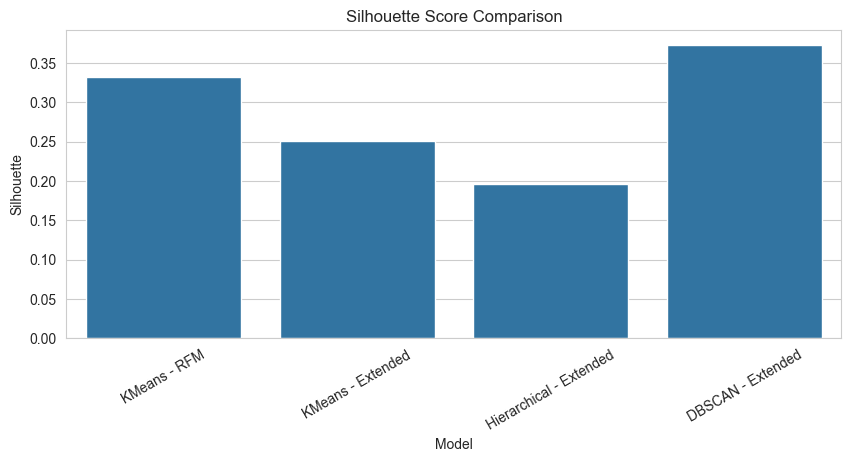

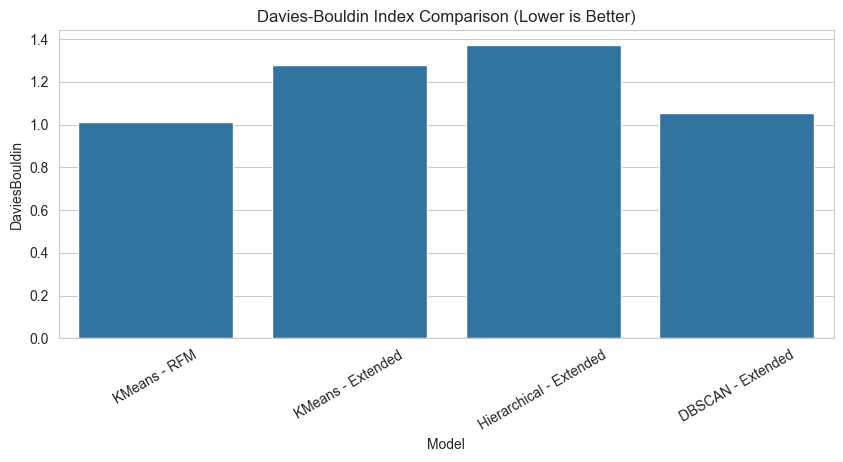

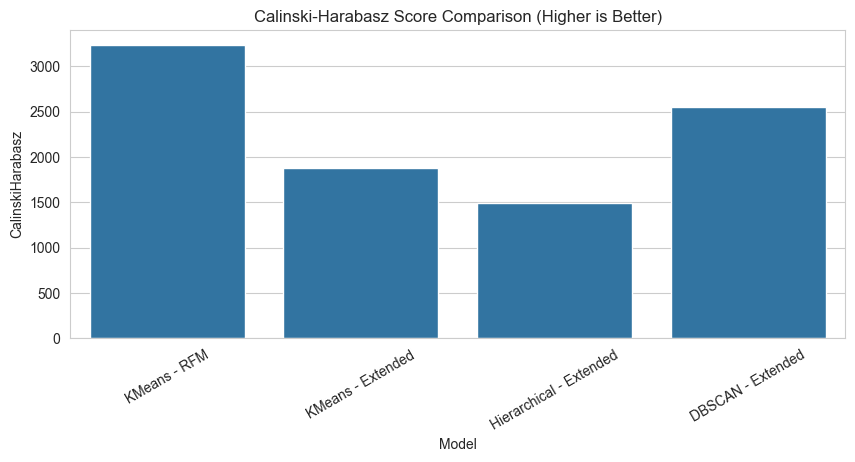

In [189]:
plot_results = results.copy()
plot_results["Model"] = plot_results["Method"] + " - " + plot_results["FeatureSet"]

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_results, x="Model", y="Silhouette")
plt.title("Silhouette Score Comparison")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_results, x="Model", y="DaviesBouldin")
plt.title("Davies-Bouldin Index Comparison (Lower is Better)")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_results, x="Model", y="CalinskiHarabasz")
plt.title("Calinski-Harabasz Score Comparison (Higher is Better)")
plt.xticks(rotation=30)
plt.show()


## 20. PCA Visualization Function

We reduce feature dimensions using PCA and visualize clusters in 2D space.

This helps:
- Observe cluster separation
- Compare clustering methods visually


In [190]:
def plot_pca_clusters(X, labels, title):
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    pca_data = pca.fit_transform(X)

    plt.figure(figsize=(8, 6))
    plt.scatter(pca_data[:, 0], pca_data[:, 1], c=labels, alpha=0.7)
    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.show()


## 21. PCA Projections of All Models


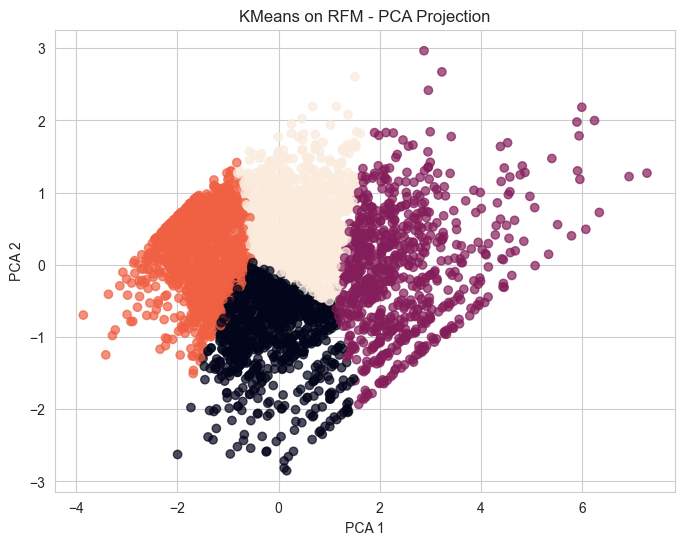

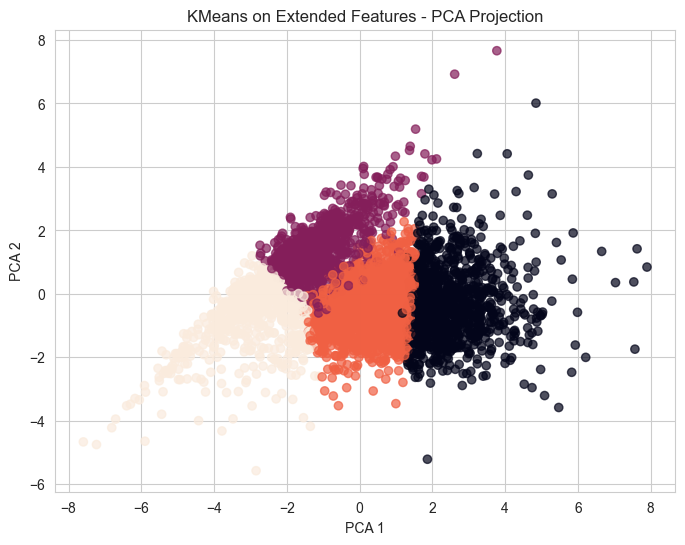

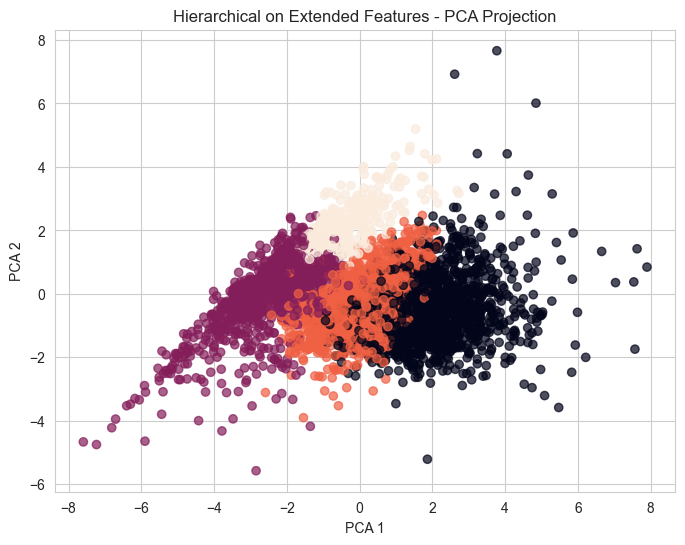

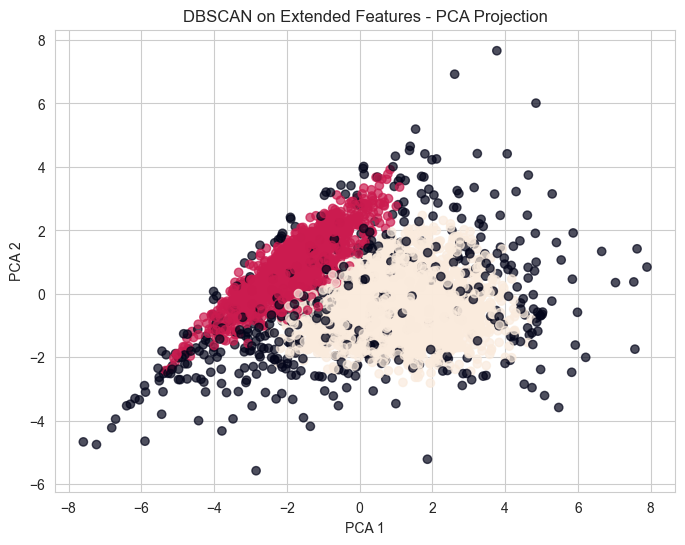

In [191]:
plot_pca_clusters(rfm_scaled, labels_kmeans_rfm, "KMeans on RFM - PCA Projection")
plot_pca_clusters(ext_scaled, labels_kmeans_ext, "KMeans on Extended Features - PCA Projection")
plot_pca_clusters(ext_scaled, labels_agg_ext, "Hierarchical on Extended Features - PCA Projection")
plot_pca_clusters(ext_scaled, labels_dbscan_ext, "DBSCAN on Extended Features - PCA Projection")


## 22. Choose the Best Model

We choose the model with the highest valid silhouette score as a simple rule for Checkpoint 2.

We select the best model based on evaluation metrics, primarily silhouette score.

The selected model is used for final segmentation and analysis

In [192]:
valid_results = results.dropna(subset=["Silhouette"]).copy()
best_row = valid_results.sort_values("Silhouette", ascending=False).iloc[0]
best_row


Method                   DBSCAN
FeatureSet             Extended
ClustersFound                 2
NoisePoints                 566
Silhouette             0.373154
DaviesBouldin          1.052932
CalinskiHarabasz    2548.110858
Name: 3, dtype: object

## 23. Attach Best Labels to the Corresponding Dataset


In [193]:
best_method = best_row["Method"]
best_featureset = best_row["FeatureSet"]

if best_method == "KMeans" and best_featureset == "RFM":
    best_labels = labels_kmeans_rfm
    best_feature_data = rfm_only.copy()
    best_scaled = rfm_scaled
elif best_method == "KMeans" and best_featureset == "Extended":
    best_labels = labels_kmeans_ext
    best_feature_data = extended.copy()
    best_scaled = ext_scaled
elif best_method == "Hierarchical":
    best_labels = labels_agg_ext
    best_feature_data = extended.copy()
    best_scaled = ext_scaled
else:
    best_labels = labels_dbscan_ext
    best_feature_data = extended.copy()
    best_scaled = ext_scaled

best_feature_data["Cluster"] = best_labels
best_feature_data.head()


,Customer ID,Recency,Frequency,Monetary,AvgOrderValue,AvgQtyPerInvoice,UniqueProducts,PurchaseSpan,Cluster
0,12346.0,165,11,372.86,33.896364,6.363636,26,196,-1
1,12347.0,3,2,1323.32,661.660000,414.000000,70,37,-1
2,12348.0,74,1,222.16,222.160000,373.000000,20,0,0
3,12349.0,43,3,2671.14,890.380000,331.000000,90,181,1
4,12351.0,11,1,300.93,300.930000,261.000000,21,0,0


## 24. Cluster Size Distribution for Best Model

We analyze the final clusters:

- Cluster size distribution
- Average feature values per cluster
- Heatmap of cluster profiles
- Normalized comparison across clusters

This helps interpret customer behavior patterns.


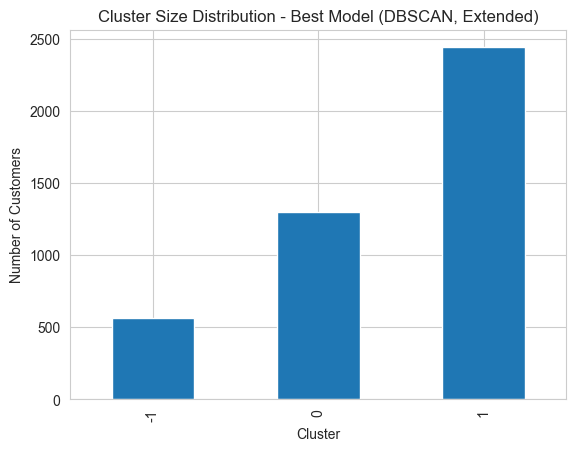

In [194]:
best_feature_data["Cluster"].value_counts().sort_index().plot(kind="bar")
plt.title(f"Cluster Size Distribution - Best Model ({best_method}, {best_featureset})")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()


## 25. Cluster Profile Summary


In [195]:
cluster_profile = best_feature_data.groupby("Cluster").mean(numeric_only=True)
cluster_profile


,Customer ID,Recency,Frequency,Monetary,AvgOrderValue,AvgQtyPerInvoice,UniqueProducts,PurchaseSpan
Cluster,,,,,,,,
-1,15313.556537,90.772085,9.162544,6874.482800,666.825725,659.432252,67.904594,130.915194
0,15406.977727,152.923195,1.022273,314.804341,308.493385,188.807988,22.912442,0.011521
1,15326.833879,58.367430,5.194763,1853.997855,348.709256,197.927162,84.360065,206.092062


## 26. Heatmap of Cluster Profiles


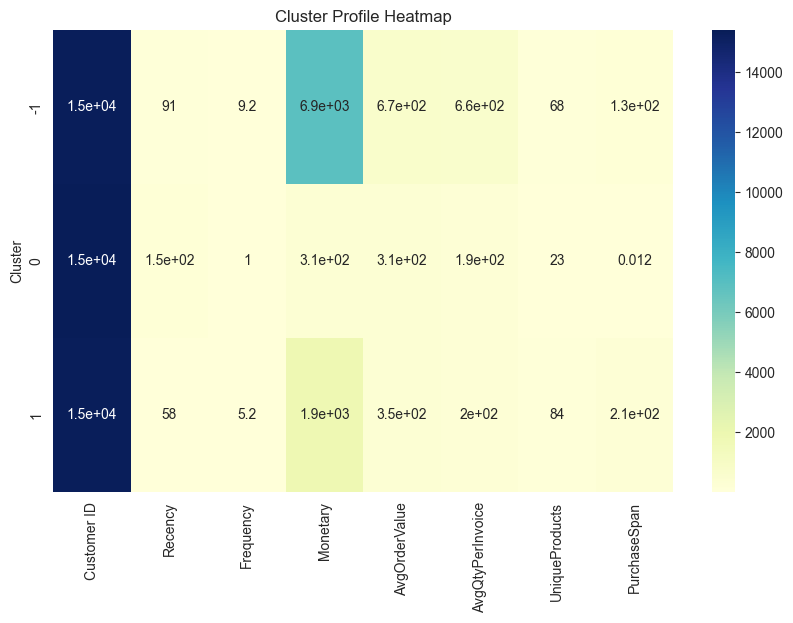

In [196]:
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile, annot=True, cmap="YlGnBu")
plt.title("Cluster Profile Heatmap")
plt.show()


## 27. Normalized Cluster Comparison


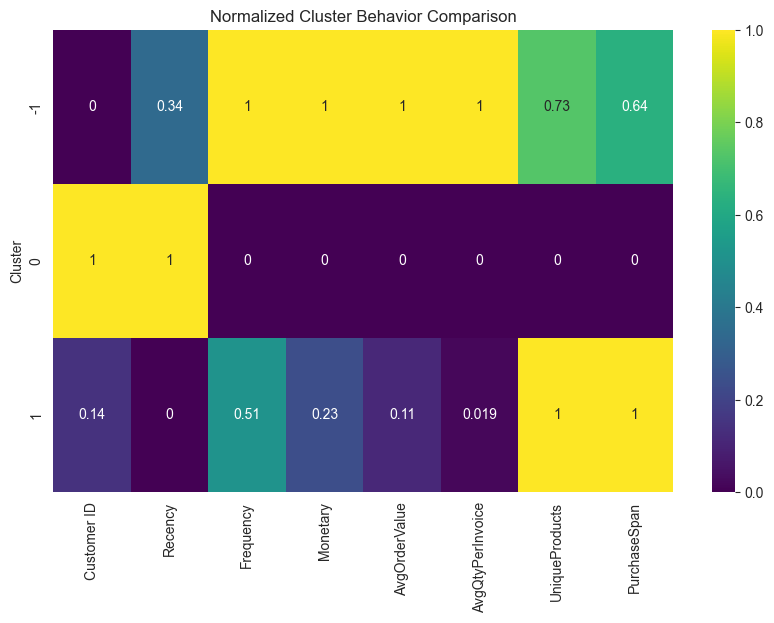

In [197]:
normalized_profile = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())

plt.figure(figsize=(10, 6))
sns.heatmap(normalized_profile, annot=True, cmap="viridis")
plt.title("Normalized Cluster Behavior Comparison")
plt.show()


## 28. Final PCA Plot for Best Model


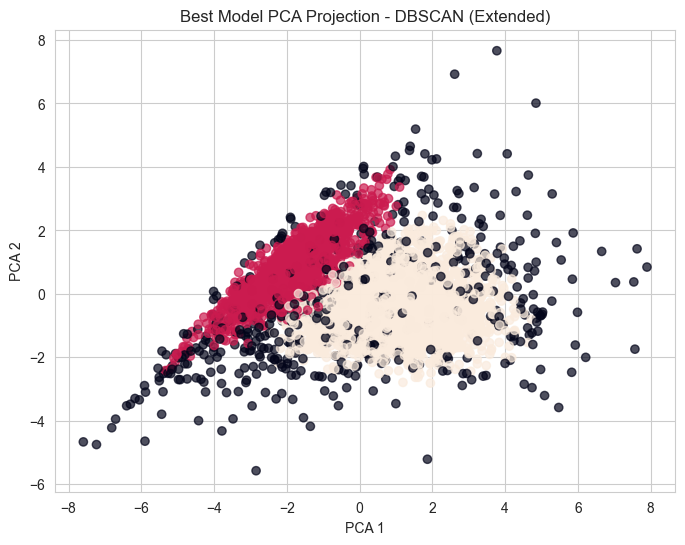

In [198]:
plot_pca_clusters(best_scaled, best_labels, f"Best Model PCA Projection - {best_method} ({best_featureset})")


## 29. Preliminary Cluster Naming Helper

The table below shows the average feature values for each cluster produced by the selected model.

Cluster labels should be assigned based on the actual behavioral characteristics of each cluster, not from a fixed list.

For this run:
- **Champions**: lower Recency, higher Frequency, and higher Monetary value
- **At Risk**: high Recency with low Frequency and low Monetary value
- **Outliers**: DBSCAN noise points labeled as -1, representing unusual customer behavior patterns

This step converts technical clustering results into business-interpretable customer segments.

In [199]:
print("Cluster Profile (Use this to assign labels):")
display(cluster_profile)

print("\nInterpretation Rules:")
print("- Low Recency = more recent customers (good)")
print("- High Recency = inactive customers (at risk)")
print("- High Frequency = loyal customers")
print("- High Monetary = high-value customers")
print("- Cluster -1 (if present) = Outliers (DBSCAN noise)")

Cluster Profile (Use this to assign labels):


,Customer ID,Recency,Frequency,Monetary,AvgOrderValue,AvgQtyPerInvoice,UniqueProducts,PurchaseSpan
Cluster,,,,,,,,
-1,15313.556537,90.772085,9.162544,6874.482800,666.825725,659.432252,67.904594,130.915194
0,15406.977727,152.923195,1.022273,314.804341,308.493385,188.807988,22.912442,0.011521
1,15326.833879,58.367430,5.194763,1853.997855,348.709256,197.927162,84.360065,206.092062



Interpretation Rules:
- Low Recency = more recent customers (good)
- High Recency = inactive customers (at risk)
- High Frequency = loyal customers
- High Monetary = high-value customers
- Cluster -1 (if present) = Outliers (DBSCAN noise)


## 30. Cluster Naming Based on Actual Output

In [200]:
profile = cluster_profile.copy()
profile.index = profile["Cluster"].astype(int) if "Cluster" in profile.columns else profile.index.astype(int)

# If Cluster is also a column, drop it from feature columns
if "Cluster" in profile.columns:
    profile = profile.drop(columns=["Cluster"])

cluster_names = {}

# DBSCAN noise
if -1 in profile.index:
    cluster_names[-1] = "Outliers"

real_profile = profile.drop(index=-1, errors="ignore")

# Assign labels only to clusters that actually exist
if set(real_profile.index) == {0, 1}:
    # Higher-recency cluster -> At Risk
    at_risk_idx = real_profile["Recency"].idxmax()
    cluster_names[int(at_risk_idx)] = "At Risk"

    # Remaining real cluster -> Champions
    remaining = [idx for idx in real_profile.index if idx != at_risk_idx]
    if remaining:
        cluster_names[int(remaining[0])] = "Champions"
else:
    # Generic fallback if the clustering output changes
    for idx, row in real_profile.iterrows():
        recency = row["Recency"]
        frequency = row["Frequency"]
        monetary = row["Monetary"]

        if recency > real_profile["Recency"].median() and frequency <= real_profile["Frequency"].median():
            cluster_names[int(idx)] = "At Risk"
        elif monetary > real_profile["Monetary"].median() and frequency > real_profile["Frequency"].median():
            cluster_names[int(idx)] = "Champions"
        else:
            cluster_names[int(idx)] = "Potential Loyalists"

print("Final cluster names:")
print(cluster_names)

best_feature_data["ClusterName"] = best_feature_data["Cluster"].astype(int).map(cluster_names)

best_feature_data[["Cluster", "ClusterName"]].head()

Final cluster names:
{-1: 'Outliers', 0: 'At Risk', 1: 'Champions'}


,Cluster,ClusterName
0,-1,Outliers
1,-1,Outliers
2,0,At Risk
3,1,Champions
4,0,At Risk


In [201]:
best_feature_data["ClusterName"] = best_feature_data["Cluster"].map(cluster_names)

best_feature_data[["Cluster", "ClusterName"]].head()

,Cluster,ClusterName
0,-1,Outliers
1,-1,Outliers
2,0,At Risk
3,1,Champions
4,0,At Risk


In [202]:
cluster_profile

,Customer ID,Recency,Frequency,Monetary,AvgOrderValue,AvgQtyPerInvoice,UniqueProducts,PurchaseSpan
Cluster,,,,,,,,
-1,15313.556537,90.772085,9.162544,6874.482800,666.825725,659.432252,67.904594,130.915194
0,15406.977727,152.923195,1.022273,314.804341,308.493385,188.807988,22.912442,0.011521
1,15326.833879,58.367430,5.194763,1853.997855,348.709256,197.927162,84.360065,206.092062


## 31. Named Cluster Distribution


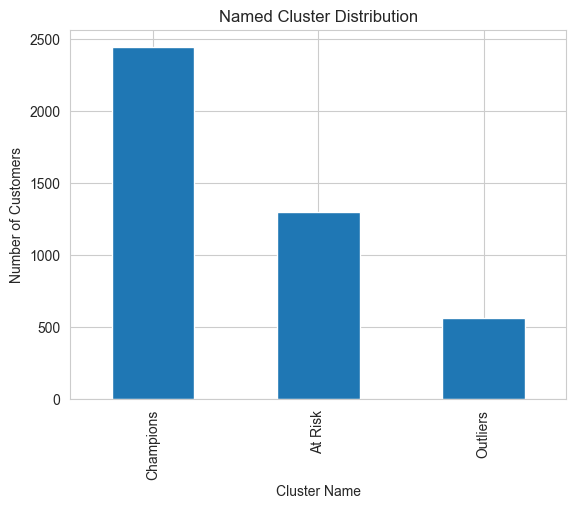

In [203]:
best_feature_data["ClusterName"].value_counts().plot(kind="bar")
plt.title("Named Cluster Distribution")
plt.xlabel("Cluster Name")
plt.ylabel("Number of Customers")
plt.show()


## 32. Final Summary for Presentation


In [204]:
print("Best Model:", best_method)
print("Best Feature Set:", best_featureset)
print("\nEvaluation Metrics:")
print(best_row)

print("\nCluster Names:")
print(cluster_names)

print("\nCluster Profile:")
print(cluster_profile)


Best Model: DBSCAN
Best Feature Set: Extended

Evaluation Metrics:
Method                   DBSCAN
FeatureSet             Extended
ClustersFound                 2
NoisePoints                 566
Silhouette             0.373154
DaviesBouldin          1.052932
CalinskiHarabasz    2548.110858
Name: 3, dtype: object

Cluster Names:
{-1: 'Outliers', 0: 'At Risk', 1: 'Champions'}

Cluster Profile:
          Customer ID     Recency  Frequency     Monetary  AvgOrderValue  \
Cluster                                                                    
-1       15313.556537   90.772085   9.162544  6874.482800     666.825725   
 0       15406.977727  152.923195   1.022273   314.804341     308.493385   
 1       15326.833879   58.367430   5.194763  1853.997855     348.709256   

         AvgQtyPerInvoice  UniqueProducts  PurchaseSpan  
Cluster                                                  
-1             659.432252       67.904594    130.915194  
 0             188.807988       22.912442      0.0

## 33. Save Outputs


In [206]:
os.makedirs("outputs", exist_ok=True)

results.to_csv("outputs/checkpoint2_model_comparison.csv", index=False)
cluster_profile.to_csv("outputs/checkpoint2_cluster_profile.csv")
best_feature_data.to_csv("outputs/checkpoint2_best_model_customers.csv", index=False)

print("Files saved:")
print("- outputs/checkpoint2_model_comparison.csv")
print("- outputs/checkpoint2_cluster_profile.csv")
print("- outputs/checkpoint2_best_model_customers.csv")


Files saved:
- outputs/checkpoint2_model_comparison.csv
- outputs/checkpoint2_cluster_profile.csv
- outputs/checkpoint2_best_model_customers.csv


## 34. Conclusion

In this notebook, we:
- reused the Checkpoint 1 segmentation pipeline
- engineered additional customer behavior features
- compared K-Means, Hierarchical Clustering, and DBSCAN
- evaluated methods using clustering metrics
- selected the best-performing model
- interpreted final customer segments

This provides a stronger and more complete customer segmentation pipeline for Checkpoint 2.
